In [7]:
import sys
from pathlib import Path

sys.path.insert(0, '../../')
import numpy as np
from matplotlib import pyplot as plt

import lsstypes as types
from clustering_statistics import tools, box_tools

plot_dir = Path('validation_imaging_systematics')
plot_dir.mkdir(exist_ok=True)
ext = 'pdf'

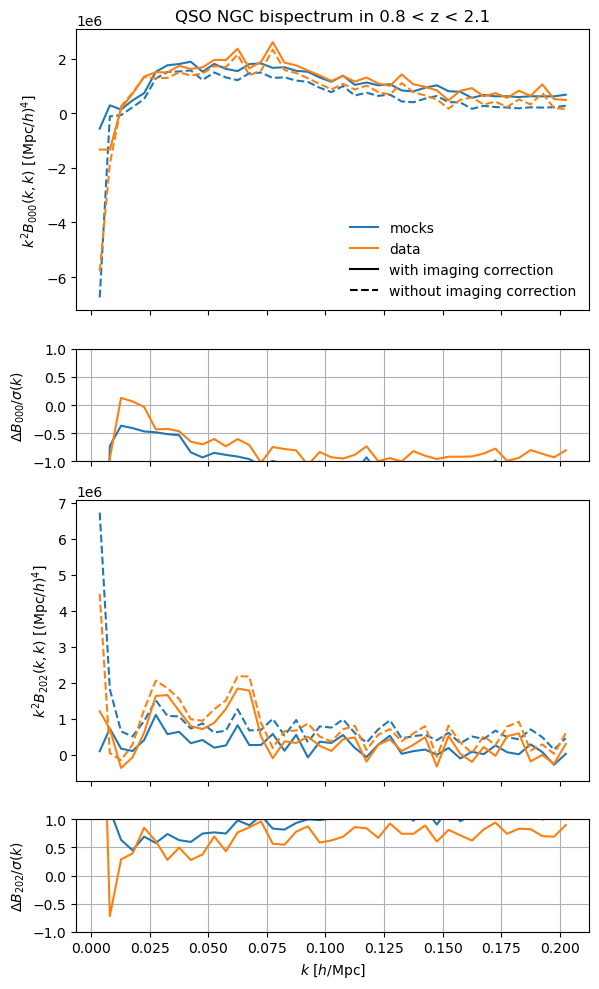

In [18]:
cont_dir = Path('/pscratch/sd/a/adematti/measurements')

tracer = 'QSO'
zrange = (0.8, 2.1)
region = 'NGC'
nmocks = 5
version = 'abacus-hf-dr2-v2-altmtl'

for kind in ['mesh2_spectrum', 'mesh3_spectrum'][1:]:

    version = 'holi-v3-altmtl'
    if 'BGS' in tracer:
        version = 'holi-bgs-altmtl'
        tracer = 'BGS_BRIGHT-21.35'
    fns = [tools.get_stats_fn(stats_dir=tools.base_stats_dir, kind=kind, project='full_shape/base', version=version, tracer=tracer,
                              zrange=zrange, region=region, weight='default-FKP', basis='sugiyama-diagonal', imock=imock) for imock in range(50)]

    mocks = [types.read(fn) for fn in fns if fn.exists()]
    cov = types.cov(mocks)
    cov = cov.at.observable.select(k=slice(0, None, 5 if 'mesh2' in kind else 1))

    version = 'abacus-hf-dr2-v2-altmtl'
    fns = [tools.get_stats_fn(stats_dir=tools.base_stats_dir, kind=kind, project='full_shape/fiber_assignment_systematics',
                              version=version, tracer=tracer, zrange=zrange, region=region,
                              weight='default-FKP', basis='sugiyama-diagonal',
                              imock=imock) for imock in range(nmocks)]

    mocks = [types.read(fn) for fn in fns if fn.exists()]
    mean = types.mean(mocks).match(cov.observable)

    fns = [tools.get_stats_fn(stats_dir=cont_dir, kind=kind, project='full_shape/angular_systematics',
                              version=version, tracer=tracer, zrange=zrange, region=region,
                              weight='default-FKP-wsys-CONT_WEIGHT_SYS', basis='sugiyama-diagonal',
                              imock=imock) for imock in range(nmocks)]
    mocks = [types.read(fn) for fn in fns if fn.exists()]
    mean_cont = types.mean(mocks).match(cov.observable)

    fn = tools.get_stats_fn(stats_dir=tools.base_stats_dir, kind=kind,
                            project='full_shape/fiber_assignment_systematics', version='data-dr2-v2',
                            tracer=tracer, zrange=zrange, region=region, weight='default-FKP',
                            basis='sugiyama-diagonal')
    data = types.read(fn).match(cov.observable)

    fn = tools.get_stats_fn(stats_dir=tools.base_stats_dir, kind=kind,
                            project='full_shape/fiber_assignment_systematics', version='data-dr2-v2',
                            tracer=tracer, zrange=zrange, region=region, weight='default-FKP-noimsys',
                            basis='sugiyama-diagonal')
    data_noimsys = types.read(fn).match(cov.observable)

    if 'mesh2' in kind:
        ells = mean.ells
        fig, lax = plt.subplots(len(ells) * 2, figsize=(6, 10), sharex=True,
                                gridspec_kw={'height_ratios': [2.5, 1] * len(ells)})
        lax[0].set_title(f'{tracer} {region} spectrum in {zrange[0]:.1f} < z < {zrange[1]:.1f}')
        for ill, ell in enumerate(ells):
            ax = lax[2 * ill]
            ax.set_ylabel(rf'$k P_{ell:d}(k)$ [$(\mathrm{{Mpc}}/h)^2$]')

            pole = mean.get(ell)
            ax.plot(k:=pole.coords('k'), k * pole.value(), color='C0', linestyle='-')
            pole = mean_cont.get(ell)
            ax.plot(k:=pole.coords('k'), k * pole.value(), color='C0', linestyle='--')

            pole = data.get(ell)
            ax.plot(k:=pole.coords('k'), k * pole.value(), color='C1', linestyle='-')
            pole = data_noimsys.get(ell)
            ax.plot(k:=pole.coords('k'), k * pole.value(), color='C1', linestyle='--')

            ax = lax[2 * ill + 1]
            ax.set_ylabel(rf'$\Delta P_{ell:d} / \sigma(k)$')
            ax.grid(True)
            ax.set_ylim(-1., 1.)

            pole = mean.get(ell)
            pole_cont = mean_cont.get(ell)
            std = cov.at.observable.get(ell).std()
            ax.plot(k, (pole_cont.value() - pole.value()) / std, color='C0', linestyle='-')

            pole = data.get(ell)
            pole_noimsys = data_noimsys.get(ell)
            ax.plot(k, (pole_noimsys.value() - pole.value()) / std, color='C1', linestyle='-')

        ax = lax[0]
        ax.plot([], [], color='C0', linestyle='-', label='mocks')
        ax.plot([], [], color='C1', linestyle='-', label='data')
        ax.plot([], [], color='k', linestyle='-', label='with imaging correction')
        ax.plot([], [], color='k', linestyle='--', label='without imaging correction')
        lax[-1].set_xlabel(r'$k$ [$h/\mathrm{Mpc}$]')
        ax.legend(frameon=False)

    elif 'mesh3' in kind:
        ells = mean.ells
        fig, lax = plt.subplots(len(ells) * 2, figsize=(6, 10), sharex=True,
                                gridspec_kw={'height_ratios': [2.5, 1] * len(ells)})
        lax[0].set_title(f'{tracer} {region} bispectrum in {zrange[0]:.1f} < z < {zrange[1]:.1f}')
        for ill, ell in enumerate(ells):
            ax = lax[2 * ill]
            ax.set_ylabel(rf'$k^2 B_{{{ell[0]:d}{ell[1]:d}{ell[2]:d}}}(k, k)$ [$(\mathrm{{Mpc}}/h)^4$]')

            pole = mean.get(ell)
            ax.plot(k:=pole.coords('k')[..., 0], k**2 * pole.value(), color='C0', linestyle='-')
            pole = mean_cont.get(ell)
            ax.plot(k:=pole.coords('k')[..., 0], k**2 * pole.value(), color='C0', linestyle='--')

            pole = data.get(ell)
            ax.plot(k:=pole.coords('k')[..., 0], k**2 * pole.value(), color='C1', linestyle='-')
            pole = data_noimsys.get(ell)
            ax.plot(k:=pole.coords('k')[..., 0], k**2 * pole.value(), color='C1', linestyle='--')

            ax = lax[2 * ill + 1]
            ax.set_ylabel(rf'$\Delta B_{{{ell[0]:d}{ell[1]:d}{ell[2]:d}}} / \sigma(k)$')
            ax.grid(True)
            ax.set_ylim(-1., 1.)

            pole = mean.get(ell)
            pole_cont = mean_cont.get(ell)
            std = cov.at.observable.get(ell).std()
            ax.plot(k, (pole_cont.value() - pole.value()) / std, color='C0', linestyle='-')

            pole = data.get(ell)
            pole_noimsys = data_noimsys.get(ell)
            ax.plot(k, (pole_noimsys.value() - pole.value()) / std, color='C1', linestyle='-')

        ax = lax[0]
        ax.plot([], [], color='C0', linestyle='-', label='mocks')
        ax.plot([], [], color='C1', linestyle='-', label='data')
        ax.plot([], [], color='k', linestyle='-', label='with imaging correction')
        ax.plot([], [], color='k', linestyle='--', label='without imaging correction')
        lax[-1].set_xlabel(r'$k$ [$h/\mathrm{Mpc}$]')
        ax.legend(frameon=False)

    basename = f'comparison_cont_weight_sys_{kind}_{tracer}_z{zrange[0]:.1f}-{zrange[1]:.1f}_{region}.{ext}'
    plt.tight_layout()
    fig.savefig(plot_dir / basename, bbox_inches='tight', pad_inches=0.1, dpi=200)
    plt.show()